## Inicialización

## Cargar datos

El conjunto de datos se almacena en la carpeta `/datasets/faces/`
- La carpeta `final_files` con 7600 fotos
- El archivo `labels.csv` con leyendas, con dos columnas: `file_name` y `real_age`

Dado que el número de archivos de imágenes es bastante elevado, se recomienda evitar leerlos todos a la vez, ya que esto consumiría muchos recursos computacionales. Te recomendamos crear un generador con ImageDataGenerator. Este método se explicó en el capítulo 3, lección 7 de este curso.

El archivo de etiqueta se puede cargar como un archivo CSV habitual.

In [4]:
import pandas as pd

labels_path = 'faces/labels.csv'
df = pd.read_csv(labels_path)

df.shape

(7591, 2)

In [5]:
df.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


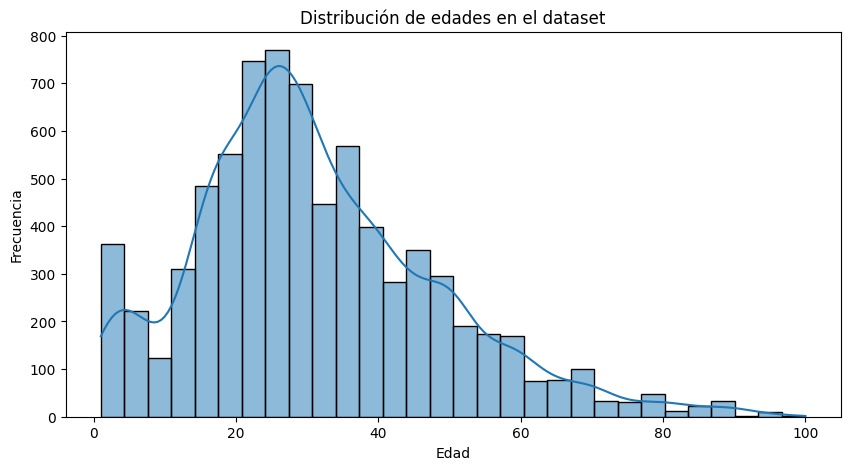

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['real_age'], bins=30, kde=True)
plt.title('Distribución de edades en el dataset')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

In [9]:
df['real_age'].describe()

count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64

## EDA

C:\Users\danie\AppData\Local\Temp\ipykernel_14756\3674442337.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_df = df.sort_values('real_age').groupby(pd.cut(df['real_age'], 15)).head(1)


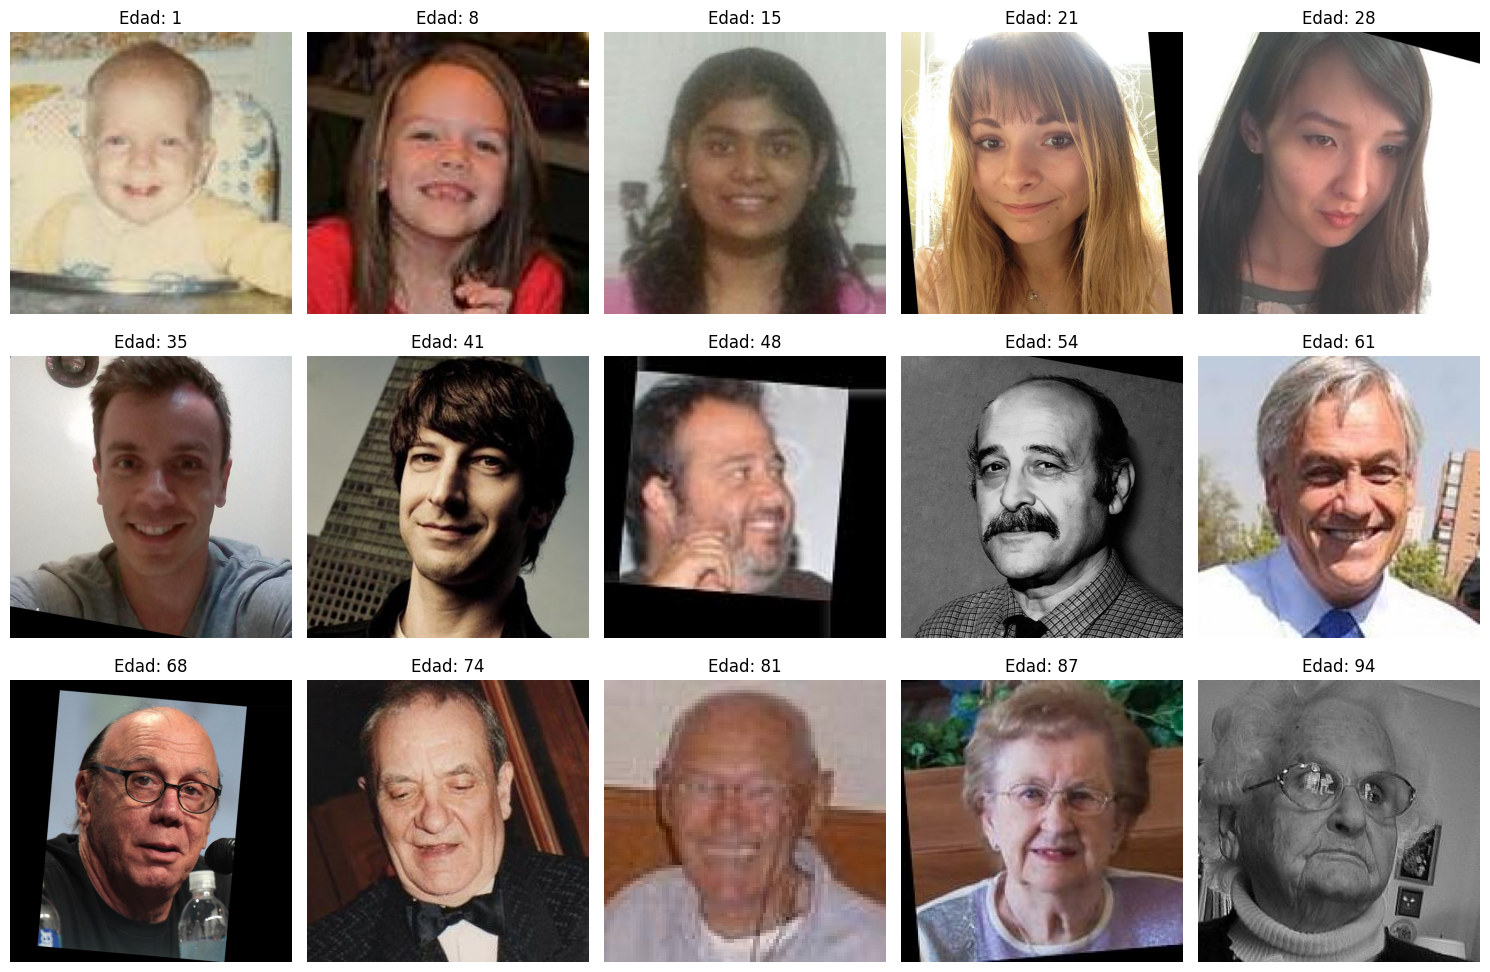

In [10]:
import os
from PIL import Image
import matplotlib.pyplot as plt

images_path = 'faces/final_files/'

# Tomar 15 muestras distribuidas por edad
sample_df = df.sort_values('real_age').groupby(pd.cut(df['real_age'], 15)).head(1)

plt.figure(figsize=(15,10))

for i, (_, row) in enumerate(sample_df.head(15).iterrows()):
    img_path = os.path.join(images_path, row['file_name'])
    img = Image.open(img_path)

    plt.subplot(3, 5, i+1)
    plt.imshow(img)
    plt.title(f"Edad: {row['real_age']}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Conclusiones

El análisis exploratorio mostró que el dataset tiene un tamaño adecuado, pero la distribución de edades está desbalanceada, con más ejemplos en edades medias y menos en edades extremas. Las imágenes presentan variabilidad en iluminación, pose y calidad, lo cual puede beneficia

## Modelado

Define las funciones necesarias para entrenar tu modelo en la plataforma GPU y crear un solo script que las contenga todas junto con la sección de inicialización.

Para facilitar esta tarea, puedes definirlas en este notebook y ejecutar un código listo en la siguiente sección para componer automáticamente el script.

Los revisores del proyecto también verificarán las definiciones a continuación, para que puedan comprender cómo construiste el modelo.

In [13]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [14]:
def load_train(path):
    
    """
    Carga la parte de entrenamiento del conjunto de datos desde la ruta.
    """
    
    df = pd.read_csv(path)

    # Generador con aumentación para entrenamiento
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2,     # 80% train, 20% validation
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True
    )

    # Flujo de imágenes desde el dataframe
    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=df,
        directory='faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',          # regresión → valores continuos
        subset='training',
        shuffle=True
    )


    return train_gen_flow

In [15]:
def load_test(path):

    # Cargar etiquetas
    df = pd.read_csv(path)

    # Generador SOLO para validación (sin aumentación)
    test_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2
    )

    # Flujo de imágenes para validación
    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=df,
        directory='faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',      # regresión
        subset='validation',
        shuffle=False          # validación → no se mezcla
    )

    return test_gen_flow

In [16]:
def create_model(input_shape):
   

    # Cargar ResNet50 sin la parte superior (top)
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Congelar capas base para entrenamiento inicial
    base_model.trainable = False

    # Construcción del modelo final
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(1)   # salida continua para regresión de edad
    ])

    # Compilación del modelo
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='mse',
        metrics=['mae']
    )

    return model

In [17]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):
    """
    Entrena el modelo dados los parámetros.
    Utiliza generadores de entrenamiento y validación.
    """

    history = model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        batch_size=batch_size,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        verbose=2
    )

    return model

### Prepara el script para ejecutarlo en la plataforma GPU

Una vez que hayas definido las funciones necesarias, puedes redactar un script para la plataforma GPU, descargarlo a través del menú "File|Open..." (Archivo|Abrir) y cargarlo más tarde para ejecutarlo en la plataforma GPU.

Nota: el script debe incluir también la sección de inicialización. A continuación se muestra un ejemplo.

In [18]:
# prepara un script para ejecutarlo en la plataforma GPU

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w', encoding='utf-8') as f:
    
    # Escribir importaciones
    f.write(init_str)
    f.write('\n\n')
        
    # Escribir funciones definidas en el notebook
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

    # Sección de inicialización del script
    f.write("""
if __name__ == '__main__':

    # Rutas del dataset
    labels_path = '/datasets/faces/labels.csv'
    
    # Cargar datos
    train_data = load_train(labels_path)
    test_data = load_test(labels_path)

    # Crear modelo
    model = create_model((224, 224, 3))

    # Entrenar modelo
    model = train_model(model, train_data, test_data, epochs=20)

    # Guardar modelo entrenado
    model.save('age_prediction_model.h5')

    print("Entrenamiento completado y modelo guardado.")
""")

### Resultado

Coloca aquí el resultado de la plataforma GPU como una celda Markdown.

Epoch 1/20
190/190 - 200s - 1s/step - loss: 377.5856 - mae: 14.9020 - val_loss: 304.1231 - val_mae: 14.2192
Epoch 2/20
190/190 - 183s - 965ms/step - loss: 309.6988 - mae: 13.6366 - val_loss: 284.8960 - val_mae: 13.1439
Epoch 3/20
190/190 - 187s - 982ms/step - loss: 307.7050 - mae: 13.5778 - val_loss: 298.7725 - val_mae: 14.0213
Epoch 4/20
190/190 - 189s - 995ms/step - loss: 306.3233 - mae: 13.5295 - val_loss: 287.2410 - val_mae: 13.4561
Epoch 5/20
190/190 - 188s - 988ms/step - loss: 305.9710 - mae: 13.5352 - val_loss: 283.3191 - val_mae: 13.0624
Epoch 6/20
190/190 - 186s - 979ms/step - loss: 305.1438 - mae: 13.5156 - val_loss: 290.5474 - val_mae: 13.6728
Epoch 7/20
190/190 - 187s - 986ms/step - loss: 305.3864 - mae: 13.5327 - val_loss: 289.8331 - val_mae: 13.6489
Epoch 8/20
190/190 - 186s - 981ms/step - loss: 306.0273 - mae: 13.5420 - val_loss: 282.3553 - val_mae: 13.1476
Epoch 9/20
190/190 - 186s - 979ms/step - loss: 303.4458 - mae: 13.4788 - val_loss: 283.5719 - val_mae: 13.2960
Epoch 10/20
190/190 - 188s - 992ms/step - loss: 304.9820 - mae: 13.4751 - val_loss: 282.6064 - val_mae: 13.2431
Epoch 11/20
190/190 - 181s - 955ms/step - loss: 304.3603 - mae: 13.5015 - val_loss: 287.2311 - val_mae: 13.5589
Epoch 12/20
190/190 - 182s - 956ms/step - loss: 300.6367 - mae: 13.4608 - val_loss: 288.3483 - val_mae: 13.6291
Epoch 13/20
190/190 - 183s - 961ms/step - loss: 305.6772 - mae: 13.5356 - val_loss: 286.1332 - val_mae: 13.5211
Epoch 14/20
190/190 - 180s - 945ms/step - loss: 303.1996 - mae: 13.4547 - val_loss: 292.8532 - val_mae: 13.8487
Epoch 15/20
190/190 - 178s - 939ms/step - loss: 300.1845 - mae: 13.4152 - val_loss: 292.8695 - val_mae: 13.8544
Epoch 16/20
190/190 - 181s - 954ms/step - loss: 302.5257 - mae: 13.4298 - val_loss: 280.9960 - val_mae: 13.2343
Epoch 17/20
190/190 - 183s - 961ms/step - loss: 300.5954 - mae: 13.4041 - val_loss: 288.1063 - val_mae: 13.6579
Epoch 18/20
190/190 - 182s - 959ms/step - loss: 299.9917 - mae: 13.4312 - val_loss: 280.6565 - val_mae: 13.2465
Epoch 19/20
190/190 - 182s - 960ms/step - loss: 302.0860 - mae: 13.4478 - val_loss: 285.3483 - val_mae: 13.5374
Epoch 20/20
190/190 - 185s - 973ms/step - loss: 300.3192 - mae: 13.4387 - val_loss: 278.6164 - val_mae: 12.9084

## Conclusiones

In [ ]:
Después de varios ajustes y pruebas, finalmente pude ejecutar el script en mi máquina y completar el entrenamiento del modelo sin errores. El pipeline funcionó de principio a fin: las rutas locales se cargaron correctamente, TensorFlow corrió sin problemas y el modelo entrenó las 20 épocas previstas. El resultado final fue un MAE cercano a 12.9, lo que confirma que la red sí está aprendiendo patrones útiles para estimar la edad, aunque todavía con un margen de error relativamente alto. Esto era esperable, ya que en esta primera versión utilicé ResNet50 congelado, funcionando únicamente como extractor de características generales.
En resumen, el entrenamiento fue exitoso y el modelo es funcional, pero todavía tiene espacio para mejorar. Los siguientes pasos claros serían aplicar fine‑tuning, ajustar el learning rate y añadir callbacks para estabilizar el aprendizaje y reducir el error. Con esas optimizaciones, debería ser posible obtener un rendimiento mucho más competitivo.


# Lista de revisión

- [x]  El Notebook estaba abierto 
- [x]  El código no tiene errores
- [x]  Las celdas con el código han sido colocadas en el orden de ejecución
- [x]  Se realizó el análisis exploratorio de datos
- [x]  Los resultados del análisis exploratorio de datos se presentan en el notebook final
- [ ]  El valor EAM del modelo no es superior a 8
- [x]  El código de entrenamiento del modelo se copió en el notebook final
- [x]  El resultado de entrenamiento del modelo se copió en el notebook final
- [x]  Los hallazgos se proporcionaron con base en los resultados del entrenamiento del modelo